# Topic Modeling
using LDA to find the hidden themes in reddit discussions about AI and Wikipedia, then tracking how the prominence of those themes shifted before and after ChatGPT launched (Nov 30, 2022).

the core business analytics question here: did the *topics* people discuss change after ChatGPT, not just the volume or sentiment? that would tell us something more specific about what concerns or interests drove the discourse shift.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from scipy import stats
from src.data_prep import add_pre_post_chatgpt

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 100

os.makedirs('../../data/processed/reddit_processed', exist_ok=True)
os.makedirs('../../reports/figures', exist_ok=True)

CHATGPT_LAUNCH = pd.Timestamp('2022-11-30')

TOPIC_LABELS = {
    1: 'Topic 1 Label',
    2: 'Topic 2 Label',
    3: 'Topic 3 Label',
    4: 'Topic 4 Label',
    5: 'Topic 5 Label',
    6: 'Topic 6 Label',
    7: 'Topic 7 Label',   # new
}
TOPIC_COLORS = [
    '#1565C0', '#42A5F5', '#26C6DA', '#EF5350', '#66BB6A', '#FFA726', '#AB47BC'  # 7 colors
]

In [3]:
df = pd.read_csv(
    '../../data/processed/reddit_processed/reddit_with_sentiment.csv',
    parse_dates=['date']
)

if 'period' not in df.columns:
    df = add_pre_post_chatgpt(df, date_col='date')

if 'combined_text' not in df.columns:
    df['combined_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
    df['combined_text'] = df['combined_text'].str.strip()

print(f'loaded {len(df)} posts')
print(f'subreddits: {df["subreddit"].value_counts().to_dict()}')
print(f'period split: pre={( df["period"]=="pre-ChatGPT").sum()}, post={(df["period"]=="post-ChatGPT").sum()}')

loaded 1591 posts
subreddits: {'ChatGPT': 450, 'MachineLearning': 293, 'singularity': 240, 'wikipedia': 205, 'OpenAI': 177, 'artificial': 162, 'technology': 64}
period split: pre=293, post=1298


LDA is sensitive to noise. the goals here are: remove URLs and HTML artifacts, lowercase everything, keep only alphabetic tokens, strip standard English stopwords plus a custom domain-specific list.

In [4]:
# words that appear in nearly every post or add no topical signal
DOMAIN_STOPWORDS = [
    # query keywords (ubiquitous by construction)
    'chatgpt', 'wikipedia', 'wiki', 'ai', 'artificial', 'intelligence',
    # reddit/web noise
    'http', 'www', 'com', 'reddit', 'post', 'comment', 'edit', 'deleted',
    'removed', 'amp', 'ampxb', 'dobalina',
    # conversational filler
    'like', 'just', 'said', 'dont', 'thats', 'youre', 'know', 'think',
    'want', 'really', 'actually', 'things', 'good', 'make', 'use', 'used',
    'using', 'way', 'does', 'did', 'right', 'need', 'help', 'work', 'feel',
    'able', 'new', 'time', 'people', 'got', 'going', 'get', 'getting',
    'lot', 'thing', 'pretty', 'bit', 'sure', 'say', 'mean', 'point',
    # contractions missed by standard stopwords
    'll', 've', 'isn', 'didn', 'wouldn', 'couldn', 'hasn', 'haven',
    'aren', 'doesnt', 'won', 'nt', 'im', 'ive', 'id', 'mr', 'gt', 'br'
]

ALL_STOPWORDS = list(ENGLISH_STOP_WORDS) + DOMAIN_STOPWORDS

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)           # URLs
    text = re.sub(r'&[a-z]+;', ' ', text)         # HTML entities
    text = re.sub(r'[^a-z\s]', '', text)           # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['combined_text'].fillna('').apply(preprocess)

# word count per post after cleaning
df['clean_word_count'] = df['clean_text'].str.split().str.len()

print('word count distribution after cleaning:')
print(df['clean_word_count'].describe().round(1))
print()
print(f'posts with < 15 words (excluded from LDA): {(df["clean_word_count"] < 15).sum()}')
print(f'posts with >= 15 words (used for LDA):     {(df["clean_word_count"] >= 15).sum()}')

word count distribution after cleaning:
count    1591.0
mean      275.9
std       523.2
min         1.0
25%        30.0
50%       107.0
75%       285.0
max      5518.0
Name: clean_word_count, dtype: float64

posts with < 15 words (excluded from LDA): 255
posts with >= 15 words (used for LDA):     1336


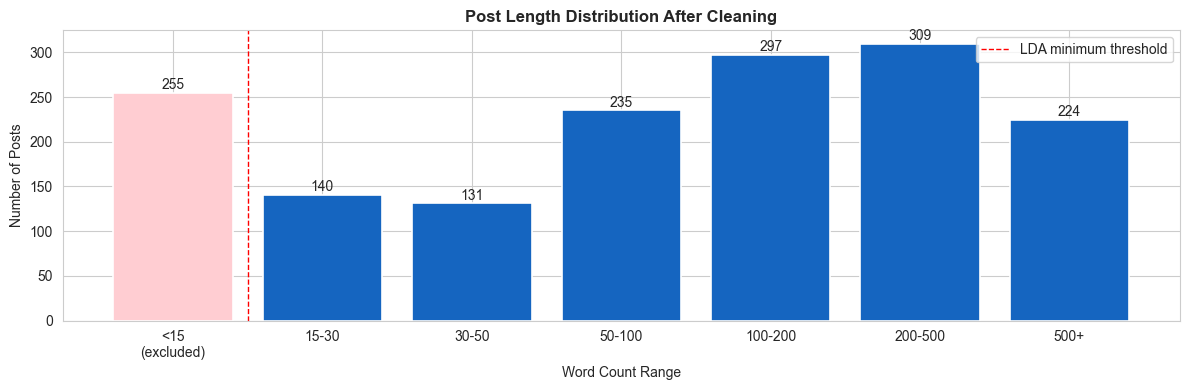

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
bins = [0, 15, 30, 50, 100, 200, 500, df['clean_word_count'].max() + 1]
labels = ['<15\n(excluded)', '15-30', '30-50', '50-100', '100-200', '200-500', '500+']
counts, _ = np.histogram(df['clean_word_count'], bins=bins)
colors = ['#FFCDD2'] + ['#1565C0'] * (len(labels) - 1)
bars = ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha='center', va='bottom', fontsize=10)
ax.set_title('Post Length Distribution After Cleaning', fontsize=12, fontweight='bold')
ax.set_xlabel('Word Count Range')
ax.set_ylabel('Number of Posts')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='LDA minimum threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../../reports/reddit_reports/tm_word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Vectorization
converting the cleaned text into a document-term matrix (DTM). using bigrams (`ngram_range=(1,2)`) alongside unigrams because phrases like `language model`, `natural language`, and `question answering` carry more meaning than their individual words. `min_df=3` drops words that appear in fewer than 3 posts (likely noise), `max_df=0.85` drops words so common they appear in 85%+ of posts.

In [6]:
# only use posts with enough words; very short posts add noise to LDA
df_lda = df[df['clean_word_count'] >= 15].copy().reset_index(drop=True)
print(f'posts going into LDA: {len(df_lda)}')

vectorizer = CountVectorizer(
    stop_words=ALL_STOPWORDS,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2),
    max_features=3000
)

dtm = vectorizer.fit_transform(df_lda['clean_text'])
vocab = vectorizer.get_feature_names_out()

print(f'DTM shape: {dtm.shape[0]} posts x {dtm.shape[1]} terms')
print(f'vocabulary size: {len(vocab)} unique tokens/bigrams')
print(f'DTM sparsity: {(1 - dtm.nnz / (dtm.shape[0] * dtm.shape[1]))*100:.1f}% zeros')
print()
print('sample vocabulary terms:')
# show mix of unigrams and bigrams
unigrams = [t for t in vocab if ' ' not in t][:15]
bigrams  = [t for t in vocab if ' ' in t][:15]
print('  unigrams:', unigrams)
print('  bigrams: ', bigrams)

posts going into LDA: 1336
DTM shape: 1336 posts x 3000 terms
vocabulary size: 3000 unique tokens/bigrams
DTM sparsity: 97.7% zeros

sample vocabulary terms:
  unigrams: ['abilities', 'ability', 'absolute', 'absolutely', 'abstract', 'abstractive', 'academic', 'accept', 'accepted', 'access', 'accessed', 'accessible', 'according', 'account', 'accountability']
  bigrams:  ['answer question', 'answer questions', 'ask questions', 'bing chat', 'charlie kirk', 'chat gpt', 'climate change', 'computer vision', 'context window', 'data points', 'data set', 'deep learning', 'deep research', 'donald trump', 'elon musk']


## Selecting the Number of Topics
LDA requires you to specify k (number of topics) upfront. tested k=4 through k=10 using log-likelihood (higher is better) and perplexity (lower is better). beyond the metrics, topic interpretability matter, too few topics and everything blurs together, too many and topics become redundant or incoherent.

In [7]:
k_range = range(4, 11)
log_likelihoods = []
perplexities    = []

print('fitting LDA for k=4 to k=10...')
for k in k_range:
    lda_k = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method='online',
        max_iter=30
    )
    lda_k.fit(dtm)
    ll = lda_k.score(dtm)
    pp = lda_k.perplexity(dtm)
    log_likelihoods.append(ll)
    perplexities.append(pp)
    print(f'  k={k}: log-likelihood={ll:.1f}, perplexity={pp:.1f}')

fitting LDA for k=4 to k=10...
  k=4: log-likelihood=-1105287.7, perplexity=1824.0
  k=5: log-likelihood=-1102972.1, perplexity=1795.6
  k=6: log-likelihood=-1102461.2, perplexity=1789.3
  k=7: log-likelihood=-1100692.1, perplexity=1768.0
  k=8: log-likelihood=-1102569.9, perplexity=1790.7
  k=9: log-likelihood=-1098702.7, perplexity=1744.2
  k=10: log-likelihood=-1098689.7, perplexity=1744.1


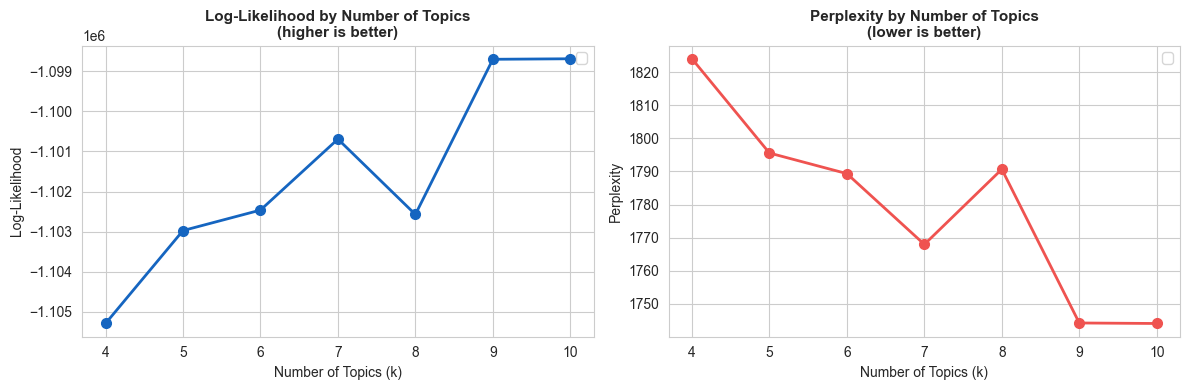

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(list(k_range), log_likelihoods, marker='o', color='#1565C0', linewidth=2, markersize=7)
ax.set_title('Log-Likelihood by Number of Topics\n(higher is better)', fontsize=11, fontweight='bold')
ax.set_xlabel('Number of Topics (k)')
ax.set_ylabel('Log-Likelihood')
ax.set_xticks(list(k_range))
ax.legend()

ax = axes[1]
ax.plot(list(k_range), perplexities, marker='o', color='#EF5350', linewidth=2, markersize=7)
ax.set_title('Perplexity by Number of Topics\n(lower is better)', fontsize=11, fontweight='bold')
ax.set_xlabel('Number of Topics (k)')
ax.set_ylabel('Perplexity')
ax.set_xticks(list(k_range))
ax.legend()

plt.tight_layout()
plt.savefig('../../reports/reddit_reports/tm_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

k=7 selected: local optimum before instability at k=8, plateau at k=9/10, 7 interpretable topics

## Fit Final LDA Model (k=7)

In [9]:
N_TOPICS = 7

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method='online',
    max_iter=30,
    learning_offset=50.0,
    doc_topic_prior=None,    # uses default 1/n_topics
    topic_word_prior=None    # uses default 1/n_topics
)

lda.fit(dtm)

# get document-topic distribution
doc_topic_matrix = lda.transform(dtm)  # shape: (n_docs, n_topics)

df_lda['dominant_topic']    = doc_topic_matrix.argmax(axis=1) + 1
df_lda['topic_confidence']  = doc_topic_matrix.max(axis=1)

# store all topic probabilities per doc
for t in range(1, N_TOPICS + 1):
    df_lda[f'topic_{t}_prob'] = doc_topic_matrix[:, t - 1]

print(f'LDA fitted on {len(df_lda)} posts')
print(f'mean topic confidence: {df_lda["topic_confidence"].mean():.3f}')
print()
print('posts per topic:')
tc = df_lda['dominant_topic'].value_counts().sort_index()
for t, n in tc.items():
    print(f'  Topic {t} ({TOPIC_LABELS[t].replace(chr(10)," ")}): {n} posts')

LDA fitted on 1336 posts
mean topic confidence: 0.703

posts per topic:
  Topic 1 (Topic 1 Label): 21 posts
  Topic 2 (Topic 2 Label): 71 posts
  Topic 3 (Topic 3 Label): 27 posts
  Topic 4 (Topic 4 Label): 647 posts
  Topic 5 (Topic 5 Label): 388 posts
  Topic 6 (Topic 6 Label): 34 posts
  Topic 7 (Topic 7 Label): 148 posts


## Topic Inspection with Top Words
the top words per topic are what let us *label* topics. LDA doesn't know what a topic means, it just finds groups of co-occurring words.

In [10]:
N_TOP_WORDS = 20

print('top words per topic:')
print('=' * 70)
for i, component in enumerate(lda.components_):
    top_idx   = component.argsort()[-N_TOP_WORDS:][::-1]
    top_words = [vocab[j] for j in top_idx]
    label     = TOPIC_LABELS[i + 1].replace('\n', ' ')
    print(f'\nTopic {i+1}: {label}')
    print('  ' + ', '.join(top_words))

top words per topic:

Topic 1: Topic 1 Label
  language, models, text, model, bert, language models, dataset, question, knowledge, sentence, english, learning, translation, natural language, pretrained, answering, natural, word, languages, generation

Topic 2: Topic 2 Label
  sources, news, real, trump, government, event, president, prediction, media, current, events, public, predictions, verdict, correct, political, death, fake, date, evidence

Topic 3: Topic 3 Label
  human, world, social, cause, article, prevent, impact, death, revolution, avoid, rights, healthy, beings, disease, evolution, lives, education, economic, king, affect

Topic 4: Topic 4 Label
  data, model, models, human, learning, information, research, training, llms, different, paper, gpt, knowledge, language, text, agi, problem, humans, better, possible

Topic 5: Topic 5 Label
  gpt, prompt, asked, chat, ask, conversation, response, information, user, answer, context, question, wrong, article, story, answers, text, t

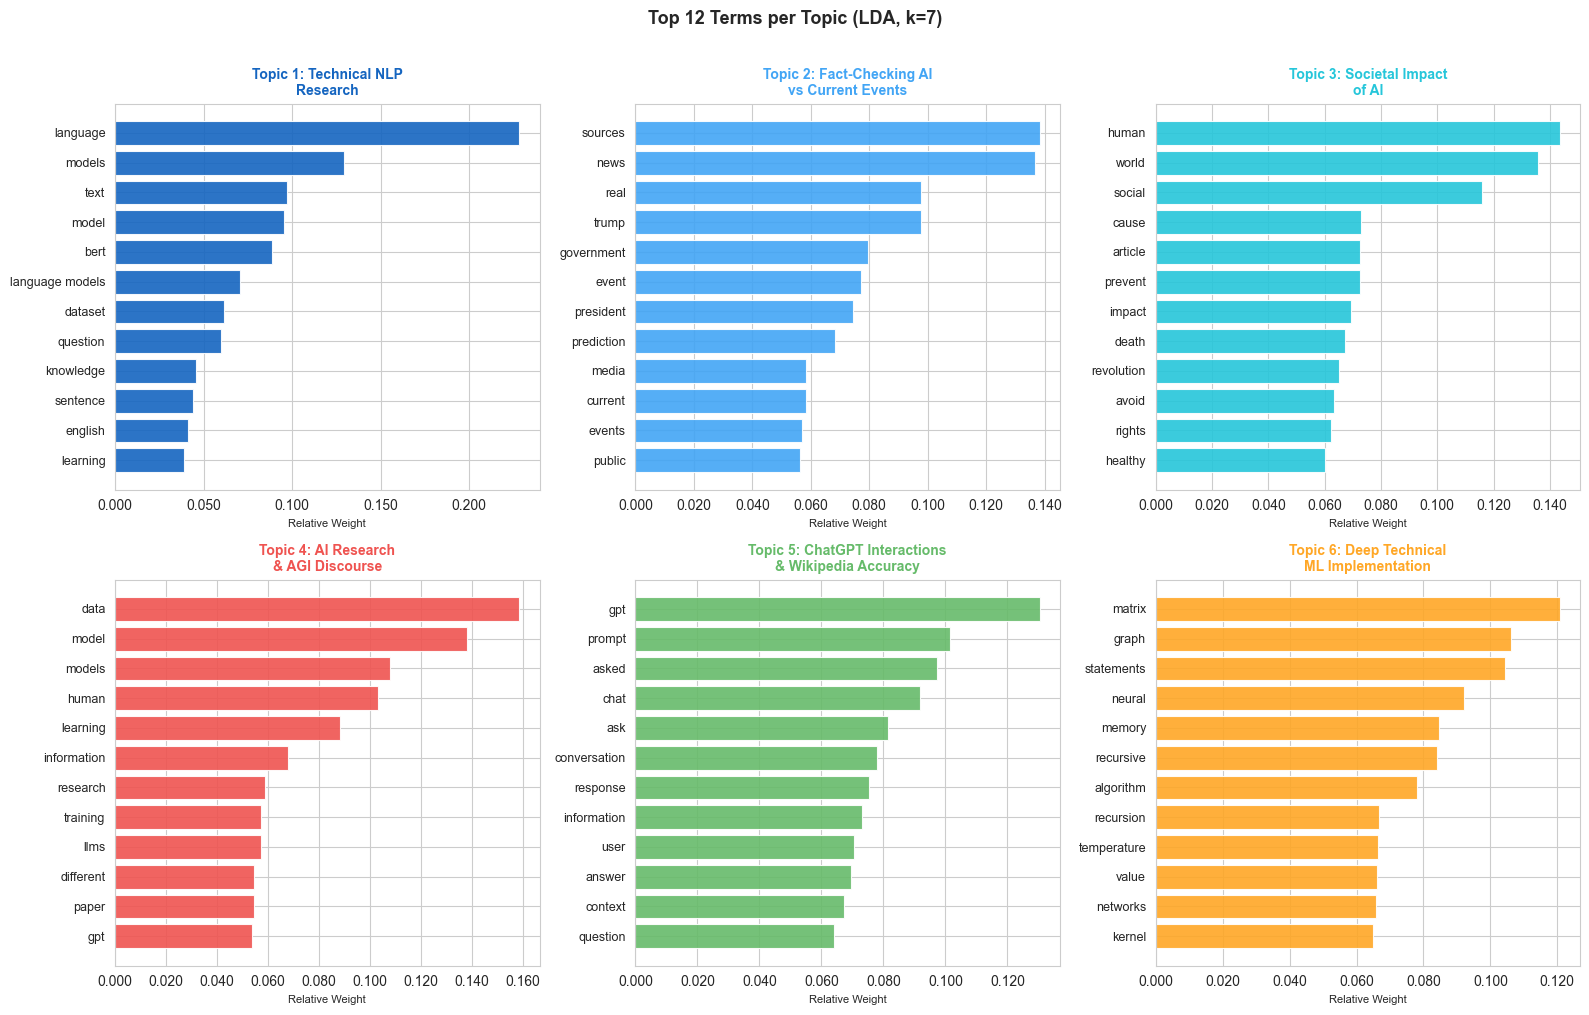

In [11]:
# horizontal bar charts of top words per topic
N_DISPLAY = 12
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

TOPIC_LABELS = {
    1: 'Technical NLP\nResearch',
    2: 'Fact-Checking AI\nvs Current Events',
    3: 'Societal Impact\nof AI',
    4: 'AI Research\n& AGI Discourse',
    5: 'ChatGPT Interactions\n& Wikipedia Accuracy',
    6: 'Deep Technical\nML Implementation',
    7: 'AI Industry\n& Corporate News',
}

for i, (ax, component) in enumerate(zip(axes, lda.components_)):
    top_idx   = component.argsort()[-N_DISPLAY:][::-1]
    top_words = [vocab[j] for j in top_idx]
    weights   = component[top_idx]
    weights   = weights / weights.sum()  # normalise to relative weight within topic

    bars = ax.barh(range(N_DISPLAY), weights[::-1], color=TOPIC_COLORS[i],
                   edgecolor='white', linewidth=0.8, alpha=0.9)
    ax.set_yticks(range(N_DISPLAY))
    ax.set_yticklabels(top_words[::-1], fontsize=9)
    ax.set_title(f'Topic {i+1}: {TOPIC_LABELS[i+1]}', fontsize=10, fontweight='bold',
                 color=TOPIC_COLORS[i])
    ax.set_xlabel('Relative Weight', fontsize=8)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))

plt.suptitle('Top 12 Terms per Topic (LDA, k=7)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../reports/reddit_reports/tm_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

 ### I determined the topic labels absed on the top words per topic.

## Representative Posts per Topic
validating topic labels. these are the posts where the dominant topic probability is highest.

In [12]:
N_EXAMPLES = 5

for t in range(1, N_TOPICS + 1):
    label   = TOPIC_LABELS[t].replace('\n', ' ')
    subset  = df_lda[df_lda['dominant_topic'] == t].nlargest(N_EXAMPLES, 'topic_confidence')
    print(f'\n{"="*70}')
    print(f'TOPIC {t}: {label}  ({len(df_lda[df_lda["dominant_topic"]==t])} posts total)')

    for _, row in subset.iterrows():
        conf = row['topic_confidence']
        print(f'  [{row["subreddit"]:>15}] conf={conf:.3f} | {str(row["title"])[:100]}')


TOPIC 1: Technical NLP Research  (21 posts total)
  [MachineLearning] conf=0.995 | [P] A list of NLP(Natural Language Processing) tutorials
  [      wikipedia] conf=0.939 | The Simple English Wikipedia is a Simple English language version of Wikipedia, an online encycloped
  [     artificial] conf=0.899 | Papers related to BERT
  [        ChatGPT] conf=0.892 | Since ChatGPT replies support Markdown and Markdown supports embedding images you can do things like
  [MachineLearning] conf=0.890 | [N] 720+ new NLP models, 300+ supported languages, translation, summarization, question answering an

TOPIC 2: Fact-Checking AI vs Current Events  (71 posts total)
  [        ChatGPT] conf=0.997 | Chatgpt claims it cannot use current news sources immediately after using current news sources becau
  [        ChatGPT] conf=0.992 | Bizarre inability to admit the existence of DOGE
  [        ChatGPT] conf=0.972 | Ask your ChatGPT who is the United States Secretary of War and who is Pete Hegseth. It's 

## Topic Distribution Overview

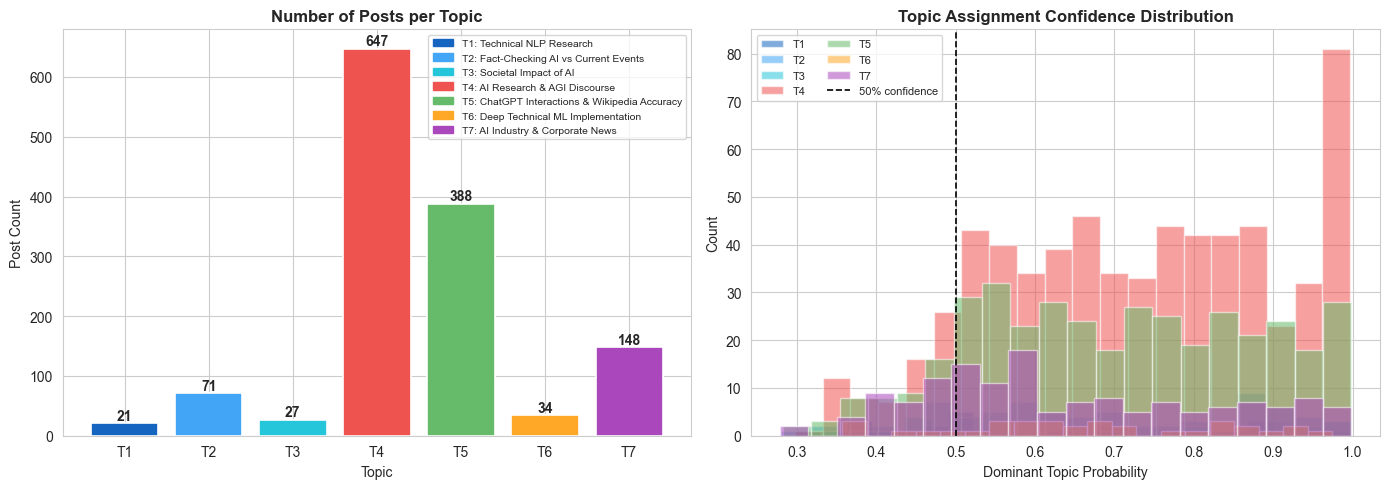

topic confidence stats:
                                     mean    min    max    std
T1: Technical NLP Research          0.631  0.364  0.995  0.211
T2: Fact-Checking AI vs Current Ev  0.667  0.280  0.997  0.185
T3: Societal Impact of AI           0.698  0.295  0.998  0.238
T4: AI Research & AGI Discourse     0.728  0.298  0.997  0.174
T5: ChatGPT Interactions & Wikiped  0.699  0.283  0.998  0.172
T6: Deep Technical ML Implementati  0.668  0.357  0.975  0.172
T7: AI Industry & Corporate News    0.642  0.278  0.999  0.180


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# topic size bar chart
ax = axes[0]
topic_counts = df_lda['dominant_topic'].value_counts().sort_index()
short_labels  = [f'T{t}' for t in topic_counts.index]
bars = ax.bar(short_labels, topic_counts.values,
              color=TOPIC_COLORS, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, topic_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Number of Posts per Topic', fontsize=12, fontweight='bold')
ax.set_xlabel('Topic')
ax.set_ylabel('Post Count')
legend_patches = [
    mpatches.Patch(color=TOPIC_COLORS[i], label=f'T{i+1}: {TOPIC_LABELS[i+1].replace(chr(10)," ")}')
    for i in range(N_TOPICS)
]
ax.legend(handles=legend_patches, fontsize=7.5, loc='upper right')

# topic confidence distribution
ax = axes[1]
for t in range(1, N_TOPICS + 1):
    conf_vals = df_lda[df_lda['dominant_topic'] == t]['topic_confidence']
    ax.hist(conf_vals, bins=20, alpha=0.55, label=f'T{t}', color=TOPIC_COLORS[t-1])
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='50% confidence')
ax.set_title('Topic Assignment Confidence Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Dominant Topic Probability')
ax.set_ylabel('Count')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('../../reports/reddit_reports/tm_topic_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# confidence stats by topic
print('topic confidence stats:')
conf_stats = df_lda.groupby('dominant_topic')['topic_confidence'].agg(['mean','min','max','std']).round(3)
conf_stats.index = [f'T{i}: {TOPIC_LABELS[i].replace(chr(10)," ")[:30]}' for i in conf_stats.index]
print(conf_stats.to_string())

## Topic Distribution by Subreddit
different communities are likely to cluster around different topics. r/artificial is more technical, r/ChatGPT more user-experience focused, r/wikipedia more concerned with content quality.

In [14]:
# raw counts
sub_topic = pd.crosstab(df_lda['subreddit'], df_lda['dominant_topic'])
sub_topic.columns = [f'T{c}' for c in sub_topic.columns]
print('post count by subreddit and topic:')
print(sub_topic.to_string())
print()

# normalised within subreddit
sub_topic_pct = sub_topic.div(sub_topic.sum(axis=1), axis=0) * 100
print('percentage of each subreddit in each topic:')
print(sub_topic_pct.round(1).to_string())

post count by subreddit and topic:
                 T1  T2  T3   T4   T5  T6  T7
subreddit                                    
ChatGPT           3  22   3   88  209   5  31
MachineLearning  10   0   1  253    8  12   4
OpenAI            1   6   2   51   59   4  24
artificial        3   6   2   82   27   0  23
singularity       0   6   6  118   36   7  38
technology        0   3   2    3    3   0   9
wikipedia         4  28  11   52   46   6  19

percentage of each subreddit in each topic:
                  T1    T2    T3    T4    T5   T6    T7
subreddit                                              
ChatGPT          0.8   6.1   0.8  24.4  57.9  1.4   8.6
MachineLearning  3.5   0.0   0.3  87.8   2.8  4.2   1.4
OpenAI           0.7   4.1   1.4  34.7  40.1  2.7  16.3
artificial       2.1   4.2   1.4  57.3  18.9  0.0  16.1
singularity      0.0   2.8   2.8  55.9  17.1  3.3  18.0
technology       0.0  15.0  10.0  15.0  15.0  0.0  45.0
wikipedia        2.4  16.9   6.6  31.3  27.7  3.6  11.4


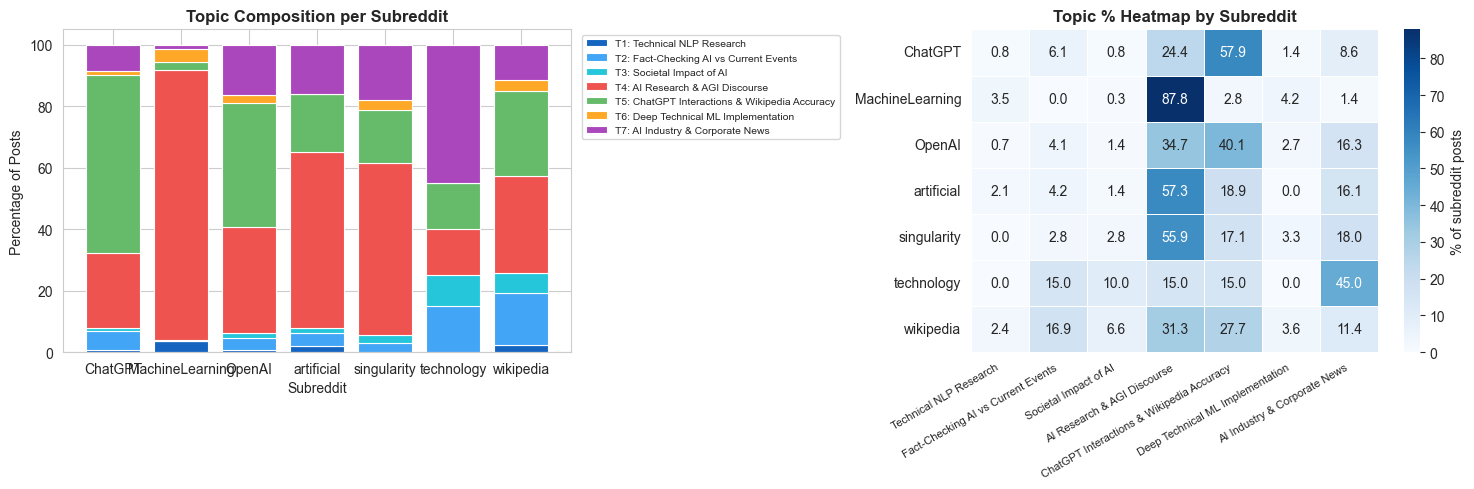

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# stacked bar: topic share per subreddit
ax = axes[0]
sub_names = sub_topic_pct.index.tolist()
bottom = np.zeros(len(sub_names))
for t_idx in range(1, N_TOPICS + 1):
    col  = f'T{t_idx}'
    vals = sub_topic_pct[col].values
    bars = ax.bar(sub_names, vals, bottom=bottom,
                  label=f'T{t_idx}: {TOPIC_LABELS[t_idx].replace(chr(10)," ")}',
                  color=TOPIC_COLORS[t_idx - 1], edgecolor='white', linewidth=0.8)
    bottom += vals

ax.set_title('Topic Composition per Subreddit', fontsize=12, fontweight='bold')
ax.set_xlabel('Subreddit')
ax.set_ylabel('Percentage of Posts')
ax.legend(fontsize=7.5, bbox_to_anchor=(1.01, 1), loc='upper left')

# heatmap: topic probability by subreddit
ax = axes[1]
heatmap_data = sub_topic_pct.copy()
heatmap_data.columns = [TOPIC_LABELS[int(c[1:])].replace('\n', ' ') for c in heatmap_data.columns]
sns.heatmap(
    heatmap_data, annot=True, fmt='.1f', cmap='Blues',
    ax=ax, linewidths=0.5, linecolor='white', cbar_kws={'label': '% of subreddit posts'}
)
ax.set_title('Topic % Heatmap by Subreddit', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../../reports/reddit_reports/tm_subreddit_topics.png', dpi=150, bbox_inches='tight')
plt.show()

## Sentiment by Topic
combining the topic labels from LDA with roberta sentiment from the previous notebook.

In [16]:
# merge roberta scores into lda dataframe
sent_cols = ['id', 'roberta_label', 'roberta_numeric', 'roberta_score', 'vader_compound']
sent_cols = [c for c in sent_cols if c in df.columns]

if 'roberta_numeric' in df.columns and 'id' in df.columns:
    df_lda = df_lda.merge(df[sent_cols], on='id', how='left', suffixes=('', '_orig'))

sent_available = 'roberta_numeric' in df_lda.columns and df_lda['roberta_numeric'].notna().any()

if sent_available:
    topic_sentiment = df_lda.groupby('dominant_topic').agg(
        n_posts=('roberta_label', 'count'),
        roberta_mean=('roberta_numeric', 'mean'),
        vader_mean=('vader_compound', 'mean'),
        positive_pct=('roberta_label', lambda x: (x=='positive').mean()*100),
        negative_pct=('roberta_label', lambda x: (x=='negative').mean()*100),
        neutral_pct=('roberta_label',  lambda x: (x=='neutral').mean()*100)
    ).round(3)
    topic_sentiment.index = [
        f'T{i}: {TOPIC_LABELS[i].replace(chr(10)," ")}' for i in topic_sentiment.index
    ]
    print('sentiment by topic:')
    print(topic_sentiment.to_string())
else:
    print('roberta scores not found in dataset. run the sentiment analysis notebook first.')

sentiment by topic:
                                               n_posts  roberta_mean  vader_mean  positive_pct  negative_pct  neutral_pct
T1: Technical NLP Research                          21        -0.095       0.585         4.762        14.286       80.952
T2: Fact-Checking AI vs Current Events              71        -0.352       0.006         4.225        39.437       56.338
T3: Societal Impact of AI                           27        -0.185       0.205        11.111        29.630       59.259
T4: AI Research & AGI Discourse                    647         0.071       0.639        14.992         7.883       77.125
T5: ChatGPT Interactions & Wikipedia Accuracy      388        -0.281       0.307        11.856        39.948       48.196
T6: Deep Technical ML Implementation                34         0.000       0.341        14.706        14.706       70.588
T7: AI Industry & Corporate News                   148        -0.014       0.414        16.892        18.243       64.865


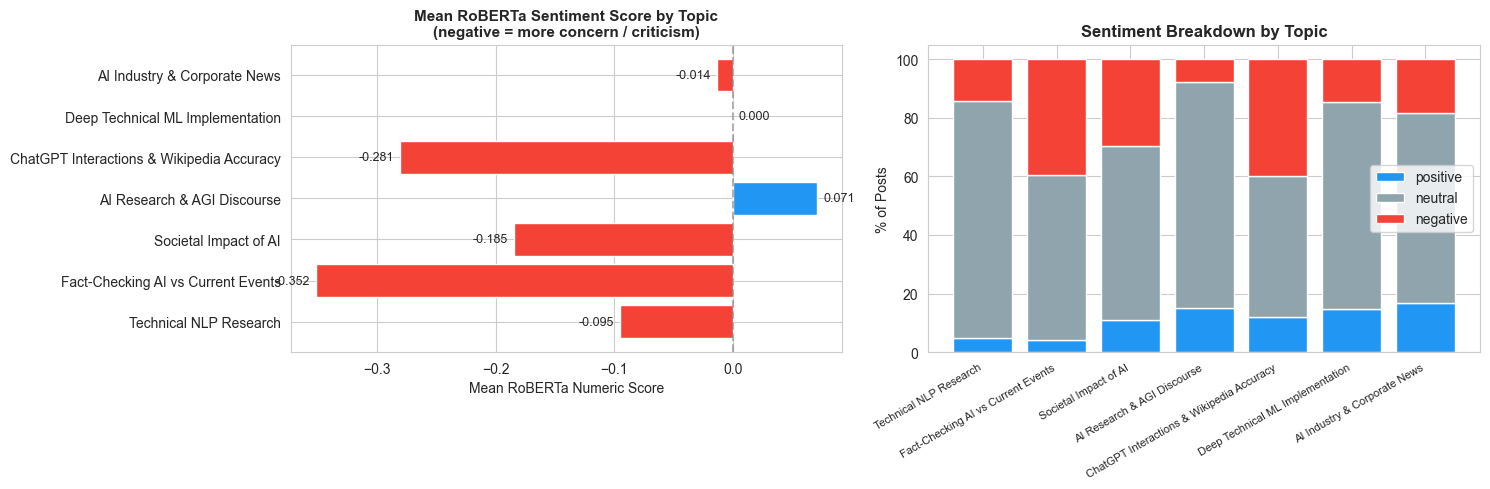

In [22]:
if sent_available:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # mean roberta score per topic
    ax = axes[0]
    means  = df_lda.groupby('dominant_topic')['roberta_numeric'].mean()
    colors = ['#F44336' if v < 0 else '#2196F3' for v in means.values]
    bars   = ax.barh(
        [TOPIC_LABELS[t].replace('\n', ' ') for t in means.index],
        means.values, color=colors, edgecolor='white', linewidth=1
    )
    ax.axvline(0, color='gray', linestyle='--', alpha=0.6)
    for bar, val in zip(bars, means.values):
        ax.text(val + (0.005 if val >= 0 else -0.005),
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=9)
    ax.set_title('Mean RoBERTa Sentiment Score by Topic\n(negative = more concern / criticism)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean RoBERTa Numeric Score')

    # sentiment stacked bar by topic
    ax = axes[1]
    topic_labels_ordered = [TOPIC_LABELS[t].replace('\n', ' ')
                             for t in sorted(df_lda['dominant_topic'].unique())]
    bottom = np.zeros(len(topic_labels_ordered))
    ts = sorted(df_lda['dominant_topic'].unique())

    for sent_label, color in [('positive', '#2196F3'), ('neutral', '#90A4AE'), ('negative', '#F44336')]:
        vals = [
            (df_lda[df_lda['dominant_topic']==t]['roberta_label'] == sent_label).mean() * 100
            for t in ts
        ]
        ax.bar(topic_labels_ordered, vals, bottom=bottom,
               label=sent_label, color=color, edgecolor='white')
        bottom += np.array(vals)

    ax.set_title('Sentiment Breakdown by Topic', fontsize=12, fontweight='bold')
    ax.set_ylabel('% of Posts')
    ax.legend()
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

    plt.tight_layout()
    plt.savefig('../../reports/reddit_reports/tm_sentiment_by_topic.png', dpi=150, bbox_inches='tight')
    plt.show()

In [25]:
# save post-level topic assignments
topic_prob_cols = [f'topic_{t}_prob' for t in range(1, N_TOPICS + 1)]

save_cols = [
    'subreddit', 'title', 'score', 'date', 'num_comments', 'id', 'period',
    'dominant_topic', 'topic_confidence'
] + [c for c in topic_prob_cols if c in df_lda.columns]

# add roberta if available
for c in ['roberta_label', 'roberta_numeric', 'vader_compound']:
    if c in df_lda.columns:
        save_cols.append(c)

df_lda[save_cols].to_csv(
    '../../data/processed/reddit_processed/reddit_with_topics.csv',
    index=False, encoding='utf-8-sig'
)
print(f'saved {len(df_lda)} posts to reddit_with_topics.csv')

# save topic-level summary
topic_summary = df_lda.groupby('dominant_topic').agg(
    topic_label=('dominant_topic', lambda x: TOPIC_LABELS[x.iloc[0]].replace('\n', ' ')),
    n_posts=('dominant_topic', 'count'),
    avg_confidence=('topic_confidence', 'mean'),
    pre_pct=('period', lambda x: (x=='pre-ChatGPT').mean()*100),
    post_pct=('period', lambda x: (x=='post-ChatGPT').mean()*100),
    median_score=('score', 'median'),
    median_comments=('num_comments', 'median')
).round(2)

if 'roberta_numeric' in df_lda.columns:
    topic_summary['roberta_mean'] = df_lda.groupby('dominant_topic')['roberta_numeric'].mean().round(3)

topic_summary.to_csv(
    '../../data/processed/reddit_processed/topic_summary.csv',
    encoding='utf-8-sig'
)
print(f'saved topic summary to topic_summary.csv')

saved 1336 posts to reddit_with_topics.csv
saved topic summary to topic_summary.csv


In [27]:
# final summary
print(f'posts included in LDA: {len(df_lda)} (posts with >= 15 words)')
print(f'vocabulary size: {len(vocab)} terms (unigrams + bigrams)')
print(f'number of topics: {N_TOPICS}')
print()
print('topic labels:')
for t in range(1, N_TOPICS + 1):
    n = (df_lda['dominant_topic'] == t).sum()
    print(f'  T{t}: {TOPIC_LABELS[t].replace(chr(10)," ")} ({n} posts, {n/len(df_lda)*100:.1f}%)')

posts included in LDA: 1336 (posts with >= 15 words)
vocabulary size: 3000 terms (unigrams + bigrams)
number of topics: 7

topic labels:
  T1: Technical NLP Research (21 posts, 1.6%)
  T2: Fact-Checking AI vs Current Events (71 posts, 5.3%)
  T3: Societal Impact of AI (27 posts, 2.0%)
  T4: AI Research & AGI Discourse (647 posts, 48.4%)
  T5: ChatGPT Interactions & Wikipedia Accuracy (388 posts, 29.0%)
  T6: Deep Technical ML Implementation (34 posts, 2.5%)
  T7: AI Industry & Corporate News (148 posts, 11.1%)
